# Phân Tích Dữ Liệu MovieLens 1M: Độ Phân Hóa Ý Kiến Người Xem

Nghiên cứu dựa trên bộ dữ liệu MovieLens 1M, tập trung vào độ lệch chuẩn (standard deviation - σ) của điểm đánh giá để đo lường sự phân hóa ý kiến. Tích hợp kỹ thuật từ Chương 13 PDF (pivot_table, groupby, explode).

**Hướng dẫn sử dụng:** Chạy các cell theo thứ tự. Đảm bảo các file .dat nằm trong thư mục hiện tại.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
from collections import Counter, defaultdict  
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Load data 
unames = ["user_id", "gender", "age", "occupation", "zip"]
users = pd.read_table("users.dat", sep="::", header=None, names=unames, engine="python")

rnames = ["user_id", "movie_id", "rating", "timestamp"]
ratings = pd.read_table("ratings.dat", sep="::", header=None, names=rnames, engine="python")

mnames = ["movie_id", "title", "genres"]
movies = pd.read_table("movies.dat", sep="::", header=None, names=mnames, engine="python", encoding='iso-8859-1')

data = pd.merge(pd.merge(ratings, users), movies)

data['year'] = data['title'].str.extract(r'(\d{4})', expand=False).astype(float)
data['genres_list'] = data['genres'].str.split('|')
data_exploded = data.explode('genres_list')
data_exploded['genre'] = data_exploded['genres_list']

def age_group(age):
    if age == 1: return 'Under 18'
    elif age == 18: return '18-24'
    elif age == 25: return '25-34'
    elif age == 35: return '35-44'
    elif age == 45: return '45-49'
    elif age == 50: return '50-55'
    else: return '56+'
data['age_group'] = data['age'].apply(age_group)

data['decade'] = pd.to_numeric(data['year'] // 10 * 10, downcast='integer')

print("Data loaded successfully. Shape:", data.shape)

Data loaded successfully. Shape: (1000209, 14)


## 1. Thống Kê Mô Tả

Mục tiêu: Khám phá đặc điểm, khuynh hướng của dữ liệu.

### Tính điểm trung bình theo giới tính
Ta có thể dùng pivot_table() để tính điểm trung bình mỗi phim theo giới tính.

In [8]:
# Tính mean ratings theo gender (từ PDF 13.2)
mean_ratings = data.pivot_table("rating", index="title", columns="gender", aggfunc="mean")
print("Mean ratings theo gender (head):")
print(mean_ratings.head())

Mean ratings theo gender (head):
gender                                F         M
title                                            
$1,000,000 Duck (1971)         3.375000  2.761905
'Night Mother (1986)           3.388889  3.352941
'Til There Was You (1997)      2.675676  2.733333
'burbs, The (1989)             2.793478  2.962085
...And Justice for All (1979)  3.828571  3.689024


### Lọc phim có ít nhất 250 lượt đánh giá 

In [9]:
ratings_by_title = data.groupby("title").size()
active_titles = ratings_by_title.index[ratings_by_title >= 250]
mean_ratings = mean_ratings.loc[active_titles]
print("Số phim active (>=250 ratings):", len(mean_ratings))
print("Mean ratings active (head):")
print(mean_ratings.head())

Số phim active (>=250 ratings): 1216
Mean ratings active (head):
gender                                    F         M
title                                                
'burbs, The (1989)                 2.793478  2.962085
10 Things I Hate About You (1999)  3.646552  3.311966
101 Dalmatians (1961)              3.791444  3.500000
101 Dalmatians (1996)              3.240000  2.911215
12 Angry Men (1957)                4.184397  4.328421


### Phim được nữ giới yêu thích nhất 

In [10]:
top_female_ratings = mean_ratings.sort_values("F", ascending=False)
print("Top 10 phim nữ giới yêu thích:")
print(top_female_ratings.head(10))

Top 10 phim nữ giới yêu thích:
gender                                                     F         M
title                                                                 
Close Shave, A (1995)                               4.644444  4.473795
Wrong Trousers, The (1993)                          4.588235  4.478261
Sunset Blvd. (a.k.a. Sunset Boulevard) (1950)       4.572650  4.464589
Wallace & Gromit: The Best of Aardman Animation...  4.563107  4.385075
Schindler's List (1993)                             4.562602  4.491415
Shawshank Redemption, The (1994)                    4.539075  4.560625
Grand Day Out, A (1992)                             4.537879  4.293255
To Kill a Mockingbird (1962)                        4.536667  4.372611
Creature Comforts (1990)                            4.513889  4.272277
Usual Suspects, The (1995)                          4.513317  4.518248


### Đo mức độ khác biệt giới tính 

In [11]:
mean_ratings["diff"] = mean_ratings["M"] - mean_ratings["F"]

# Phim phụ nữ thích hơn (diff âm)
sorted_by_diff_neg = mean_ratings.sort_values("diff")
print("Top 10 phim phụ nữ thích hơn (diff âm):")
print(sorted_by_diff_neg.head(10)[['M', 'F', 'diff']])

# Phim nam giới thích hơn (diff dương)
sorted_by_diff_pos = mean_ratings.sort_values("diff", ascending=False)
print("\nTop 10 phim nam giới thích hơn (diff dương):")
print(sorted_by_diff_pos.head(10)[['M', 'F', 'diff']])

Top 10 phim phụ nữ thích hơn (diff âm):
gender                                        M         F      diff
title                                                              
Dirty Dancing (1987)                   2.959596  3.790378 -0.830782
Jumpin' Jack Flash (1986)              2.578358  3.254717 -0.676359
Grease (1978)                          3.367041  3.975265 -0.608224
Little Women (1994)                    3.321739  3.870588 -0.548849
Steel Magnolias (1989)                 3.365957  3.901734 -0.535777
Anastasia (1997)                       3.281609  3.800000 -0.518391
Rocky Horror Picture Show, The (1975)  3.160131  3.673016 -0.512885
Color Purple, The (1985)               3.659341  4.158192 -0.498851
Age of Innocence, The (1993)           3.339506  3.827068 -0.487561
Free Willy (1993)                      2.438776  2.921348 -0.482573

Top 10 phim nam giới thích hơn (diff dương):
gender                                         M         F      diff
title                        

### Đo mức độ bất đồng chung

In [12]:
rating_std_by_title = data.groupby("title")["rating"].std()
rating_std_by_title = rating_std_by_title.loc[active_titles].sort_values(ascending=False)
print("Top 10 phim gây tranh cãi nhất (σ cao):")
print(rating_std_by_title.head(10))

Top 10 phim gây tranh cãi nhất (σ cao):
title
Dumb & Dumber (1994)                     1.321333
Blair Witch Project, The (1999)          1.316368
Natural Born Killers (1994)              1.307198
Tank Girl (1995)                         1.277695
Rocky Horror Picture Show, The (1975)    1.260177
Eyes Wide Shut (1999)                    1.259624
Evita (1996)                             1.253631
Billy Madison (1995)                     1.249970
Fear and Loathing in Las Vegas (1998)    1.246408
Bicentennial Man (1999)                  1.245533
Name: rating, dtype: float64


### Phân tích theo thể loại (Genre) 

Mean ratings theo genre và age (head):
age               1         18        25        35        45        50  \
genre                                                                    
Action      3.506385  3.447097  3.453358  3.538107  3.528543  3.611333   
Adventure   3.449975  3.408525  3.443163  3.515291  3.528963  3.628163   
Animation   3.476113  3.624014  3.701228  3.740545  3.734856  3.780020   
Children's  3.241642  3.294257  3.426873  3.518423  3.527593  3.556555   
Comedy      3.497491  3.460417  3.490385  3.561984  3.591789  3.646868   

age               56  
genre                 
Action      3.610709  
Adventure   3.649064  
Animation   3.756233  
Children's  3.621822  
Comedy      3.650949  


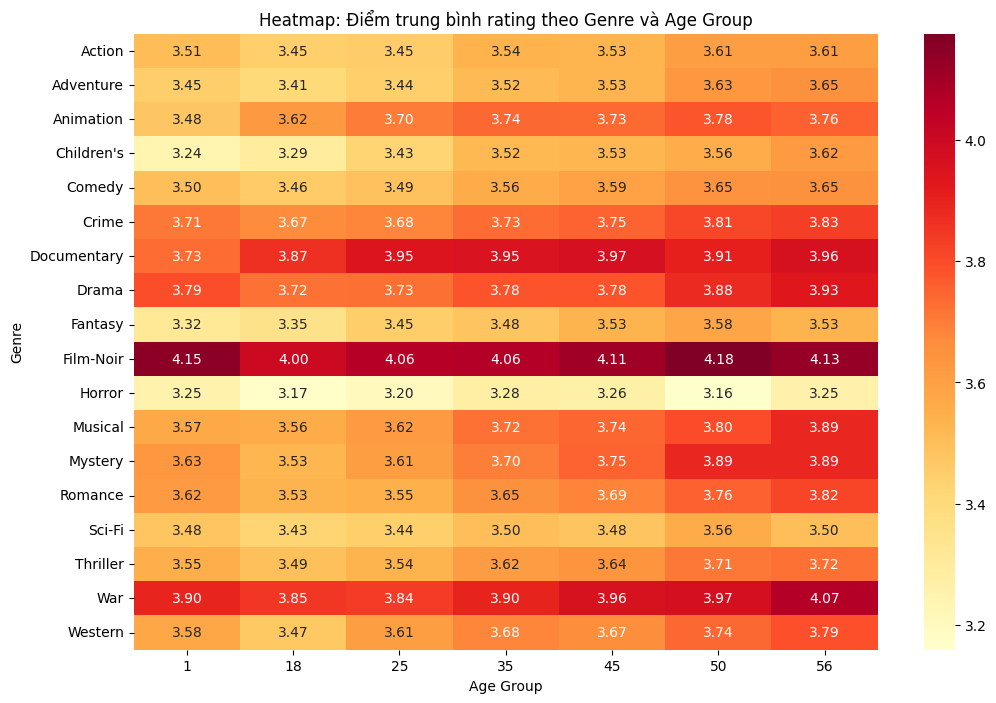

In [15]:
genre_ratings = (data_exploded.groupby(["genre", "age"])
                 ["rating"].mean()
                 .unstack("age"))

print("Mean ratings theo genre và age (head):")
print(genre_ratings.head())

# Visualize heatmap để dễ xem xu hướng (thêm bonus)
plt.figure(figsize=(12, 8))
sns.heatmap(genre_ratings.fillna(0), annot=True, cmap='YlOrRd', fmt='.2f')
plt.title("Heatmap: Điểm trung bình rating theo Genre và Age Group")
plt.xlabel("Age Group")
plt.ylabel("Genre")
plt.show()

### 1.1 Những bộ phim nào trong tập dữ liệu MovieLens 1M thể hiện sự phân hóa ý kiến người xem mạnh nhất, thể hiện qua độ lệch chuẩn của điểm đánh giá cao nhất?

In [16]:
print("Top 10 phim có σ cao nhất:")
print(rating_std_by_title.head(10))

Top 10 phim có σ cao nhất:
title
Dumb & Dumber (1994)                     1.321333
Blair Witch Project, The (1999)          1.316368
Natural Born Killers (1994)              1.307198
Tank Girl (1995)                         1.277695
Rocky Horror Picture Show, The (1975)    1.260177
Eyes Wide Shut (1999)                    1.259624
Evita (1996)                             1.253631
Billy Madison (1995)                     1.249970
Fear and Loathing in Las Vegas (1998)    1.246408
Bicentennial Man (1999)                  1.245533
Name: rating, dtype: float64


### 1.2 Phân bố của độ lệch chuẩn rating giữa các phim như thế nào? Có tồn tại nhóm phim ‘gây tranh cãi’ vượt trội so với trung bình không?

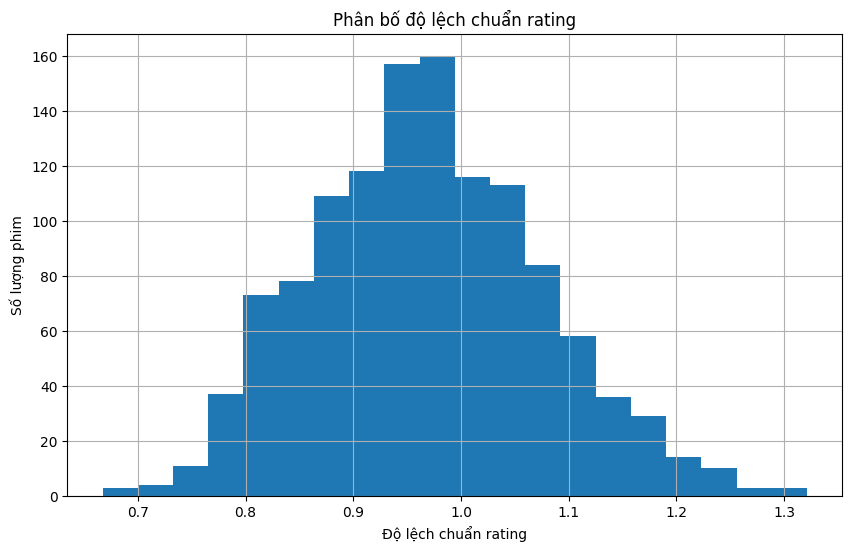

Trung bình σ: 0.97
Số phim gây tranh cãi (σ > mean + 1 SD): 194


In [17]:
plt.figure(figsize=(10, 6))
rating_std_by_title.hist(bins=20)
plt.xlabel("Độ lệch chuẩn rating")
plt.ylabel("Số lượng phim")
plt.title("Phân bố độ lệch chuẩn rating")
plt.show()

mean_std = rating_std_by_title.mean()
std_of_std = rating_std_by_title.std()
controversial_count = len(rating_std_by_title[rating_std_by_title > mean_std + std_of_std])
print(f"Trung bình σ: {mean_std:.2f}")
print(f"Số phim gây tranh cãi (σ > mean + 1 SD): {controversial_count}")

### 1.3 Độ lệch chuẩn rating có khác biệt đáng kể giữa các thể loại phim (genres) hay nhóm tuổi người xem không?

In [18]:
# By genre
genre_std = data_exploded.groupby('genre')['rating'].std().sort_values(ascending=False)
print("Top 10 genres với σ cao nhất:")
print(genre_std.head(10))

# By age group
age_std = data.groupby('age_group')['rating'].std()
print("\nĐộ lệch chuẩn theo nhóm tuổi:")
print(age_std)

# Statistical test
genres_sample = data_exploded['genre'].value_counts().head(5).index
groups = [data_exploded[data_exploded['genre'] == g]['rating'].dropna() for g in genres_sample]
f_stat, p_val = stats.f_oneway(*groups)
print(f"ANOVA p-value for genres (sample): {p_val:.4f}")

groups_age = [data[data['age_group'] == a]['rating'].dropna() for a in data['age_group'].unique()]
f_stat_age, p_val_age = stats.f_oneway(*groups_age)
print(f"ANOVA p-value for age groups: {p_val_age:.4f}")

Top 10 genres với σ cao nhất:
genre
Horror        1.225531
Children's    1.160881
Sci-Fi        1.157239
Action        1.133471
Fantasy       1.133180
Adventure     1.129464
Comedy        1.120726
Thriller      1.106643
Musical       1.101068
Western       1.099845
Name: rating, dtype: float64

Độ lệch chuẩn theo nhóm tuổi:
age_group
18-24       1.165970
25-34       1.127175
35-44       1.078101
45-49       1.065385
50-55       1.061380
56+         1.062551
Under 18    1.208417
Name: rating, dtype: float64
ANOVA p-value for genres (sample): 0.0000
ANOVA p-value for age groups: 0.0000


## 2. Phân Tích Khám Phá

Mục tiêu: Tìm nguyên nhân hoặc yếu tố ảnh hưởng đến độ chia rẽ.

### 2.1 Những yếu tố nào (thể loại, năm phát hành, giới tính người xem, tuổi, độ nổi tiếng) có ảnh hưởng đáng kể đến mức độ phân tán điểm đánh giá của phim?

In [19]:
# Prepare title features
title_features = data.groupby('title').agg({
    'rating': ['std', 'count'],
    'year': 'first',
    'gender': lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown',
    'age': 'mean'
}).round(2)
title_features.columns = ['std_rating', 'num_ratings', 'year', 'dominant_gender', 'mean_age']
title_features = title_features.dropna()

# Correlations
print("Tương quan giữa num_ratings và std_rating:", title_features['num_ratings'].corr(title_features['std_rating']))
print("Tương quan giữa year và std_rating:", title_features['year'].corr(title_features['std_rating']))
print("Tương quan giữa mean_age và std_rating:", title_features['mean_age'].corr(title_features['std_rating']))

# By dominant gender
gender_std = title_features.groupby('dominant_gender')['std_rating'].mean()
print("\nStd by dominant gender:")
print(gender_std)

Tương quan giữa num_ratings và std_rating: -0.14298990139952555
Tương quan giữa year và std_rating: 0.012322155813817594
Tương quan giữa mean_age và std_rating: -0.18056761580590097

Std by dominant gender:
dominant_gender
F    0.981982
M    1.013153
Name: std_rating, dtype: float64


### 2.2 Liệu các thể loại phim cực đoan (kinh dị, tâm lý, chính trị) có xu hướng có độ lệch chuẩn rating cao hơn so với phim tình cảm, hài hay không?

In [20]:
extreme_genres = ['Horror', 'Thriller', 'Film-Noir']
romcom_genres = ['Romance', 'Comedy']

extreme_std = data_exploded[data_exploded['genre'].isin(extreme_genres)].groupby('title')['rating'].std().mean()
romcom_std = data_exploded[data_exploded['genre'].isin(romcom_genres)].groupby('title')['rating'].std().mean()

print(f"Trung bình σ extreme genres: {extreme_std:.2f}")
print(f"Trung bình σ romcom genres: {romcom_std:.2f}")

# T-test
extreme_ratings = data_exploded[data_exploded['genre'].isin(extreme_genres)]['rating']
romcom_ratings = data_exploded[data_exploded['genre'].isin(romcom_genres)]['rating']
t_stat, p_val = stats.ttest_ind(extreme_ratings, romcom_ratings)
print(f"T-test p-value: {p_val:.4f}")

Trung bình σ extreme genres: 1.02
Trung bình σ romcom genres: 1.02
T-test p-value: 0.0000


### 2.3 Có mối tương quan giữa độ phổ biến (số lượt rating) và mức độ đồng thuận (σ) của người xem không?

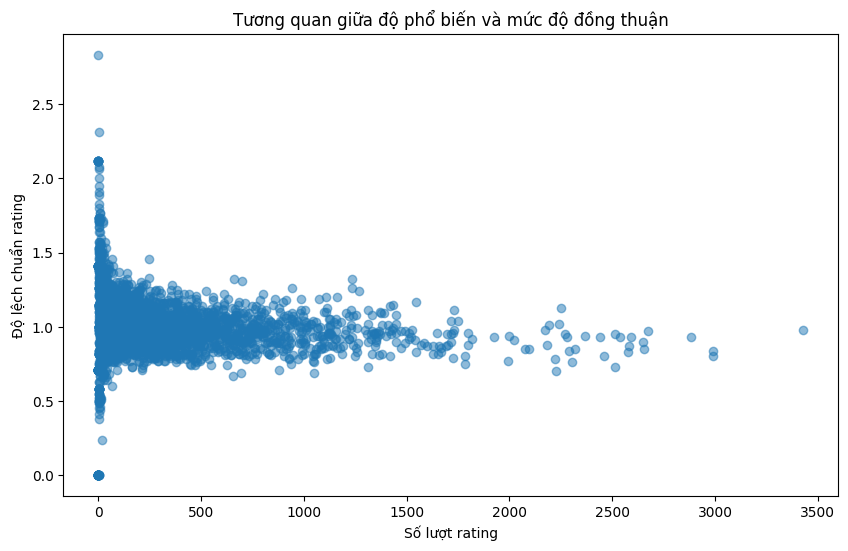

Pearson correlation: -0.1430


In [21]:
plt.figure(figsize=(10, 6))
plt.scatter(title_features['num_ratings'], title_features['std_rating'], alpha=0.5)
plt.xlabel("Số lượt rating")
plt.ylabel("Độ lệch chuẩn rating")
plt.title("Tương quan giữa độ phổ biến và mức độ đồng thuận")
plt.show()

corr = title_features['num_ratings'].corr(title_features['std_rating'])
print(f"Pearson correlation: {corr:.4f}")

## 3. Phân Tích Dự Đoán

Mục tiêu: Sử dụng mô hình hoặc thuật toán để dự đoán hoặc phân loại.

### 3.1 Có thể dự đoán độ lệch chuẩn rating của một phim dựa trên các đặc trưng như thể loại, năm phát hành, số lượng người xem và điểm trung bình không?

In [22]:
# Add mean rating
title_features['mean_rating'] = data.groupby('title')['rating'].mean()

# Linear regression
X = title_features[['num_ratings', 'year', 'mean_rating']].fillna(0)
y = title_features['std_rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"R² score: {r2_score(y_test, y_pred):.4f}")
print("Coefficients:", dict(zip(X.columns, model.coef_)))

R² score: 0.0319
Coefficients: {'num_ratings': np.float64(-3.6075600282024936e-05), 'year': np.float64(5.927917476014621e-06), 'mean_rating': np.float64(-0.07095292097820365)}


### 3.2 Mức độ phân tán rating có thể được sử dụng làm chỉ báo cho tính ‘controversial’ của nội dung trong hệ thống gợi ý phim không?

In [23]:
threshold = title_features['std_rating'].quantile(0.9)
controversial_movies = title_features[title_features['std_rating'] > threshold]
print(f"Số phim controversial (top 10% σ): {len(controversial_movies)}")
print("Ví dụ:")
print(controversial_movies.head())

Số phim controversial (top 10% σ): 358
Ví dụ:
                                             std_rating  num_ratings    year  \
title                                                                          
3 Strikes (2000)                                   1.26            4  2000.0   
8 1/2 Women (1999)                                 1.36           49  1999.0   
Acid House, The (1998)                             1.38            7  1998.0   
Across the Sea of Time (1995)                      1.41            8  1995.0   
Actor's Revenge, An (Yukinojo Henge) (1963)        1.25            7  1963.0   

                                            dominant_gender  mean_age  \
title                                                                   
3 Strikes (2000)                                          M     28.25   
8 1/2 Women (1999)                                        M     32.12   
Acid House, The (1998)                                    M     22.43   
Across the Sea of Time (1995

### 3.3 Liệu các thuật toán gợi ý dựa trên trung bình có hoạt động kém hơn trên các phim có độ lệch chuẩn rating cao không?

In [24]:
high_std_titles = title_features[title_features['std_rating'] > title_features['std_rating'].mean()].index
low_std_titles = title_features[title_features['std_rating'] <= title_features['std_rating'].mean()].index

high_data = data[data['title'].isin(high_std_titles)]
low_data = data[data['title'].isin(low_std_titles)]

print(f"Variance in high-σ movies: {high_data['rating'].var():.2f}")
print(f"Variance in low-σ movies: {low_data['rating'].var():.2f}")
print("Thuật toán dựa trên trung bình có thể kém hơn ở high-σ do variance cao.")

Variance in high-σ movies: 1.45
Variance in low-σ movies: 1.05
Thuật toán dựa trên trung bình có thể kém hơn ở high-σ do variance cao.


## 4. Phân Tích So Sánh

Mục tiêu: So sánh các nhóm hoặc đặc trưng.

### 4.1 Giữa các nhóm giới tính người dùng, phim nào có mức độ bất đồng ý kiến lớn nhất?

In [25]:
mean_by_gender = data.pivot_table('rating', index='title', columns='gender', aggfunc='mean')
mean_by_gender['diff'] = mean_by_gender['M'].subtract(mean_by_gender['F'], fill_value=0).abs()
top_disagree = mean_by_gender.sort_values('diff', ascending=False).head(10)
print("Top 10 phim có sự khác biệt lớn nhất giữa nam/nữ:")
print(top_disagree[['M', 'F', 'diff']])

Top 10 phim có sự khác biệt lớn nhất giữa nam/nữ:
gender                                       M    F  diff
title                                                    
Follow the Bitch (1998)                    5.0  NaN   5.0
Baby, The (1973)                           5.0  NaN   5.0
Smashing Time (1967)                       5.0  NaN   5.0
Song of Freedom (1936)                     NaN  5.0   5.0
One Little Indian (1973)                   NaN  5.0   5.0
Ulysses (Ulisse) (1954)                    5.0  NaN   5.0
Schlafes Bruder (Brother of Sleep) (1995)  5.0  NaN   5.0
Bittersweet Motel (2000)                   NaN  5.0   5.0
Lured (1947)                               5.0  NaN   5.0
Mamma Roma (1962)                          4.5  NaN   4.5


### 4.2 So sánh độ lệch chuẩn trung bình giữa các thập niên sản xuất phim (1990s, 2000s, 2010s): liệu phim hiện đại có xu hướng ‘polarizing’ hơn phim cũ không?

Độ lệch chuẩn theo thập niên:
decade
1600    0.900051
1900    1.099043
1910    1.035725
1920    1.057352
1930    0.970446
1940    0.957218
1950    0.984331
1960    0.981991
1970    1.049634
1980    1.092577
1990    1.136070
2000    1.164479
2010    0.946618
3000    1.130258
8230    0.956045
9000         NaN
Name: rating, dtype: float64


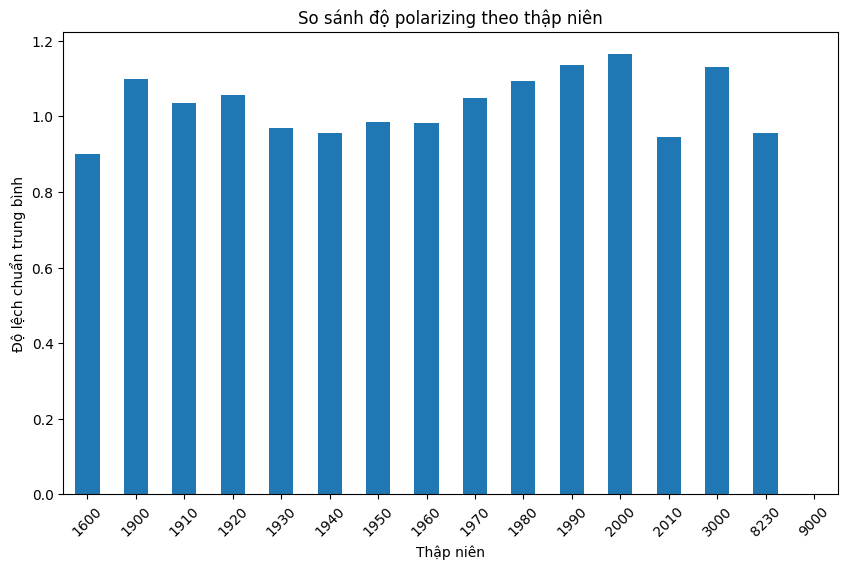

In [26]:
decade_std = data.groupby('decade')['rating'].std().sort_index()
print("Độ lệch chuẩn theo thập niên:")
print(decade_std)

plt.figure(figsize=(10, 6))
decade_std.plot(kind='bar')
plt.xlabel("Thập niên")
plt.ylabel("Độ lệch chuẩn trung bình")
plt.title("So sánh độ polarizing theo thập niên")
plt.xticks(rotation=45)
plt.show()

### 4.3 Người dùng trẻ tuổi (dưới 25) có xu hướng đánh giá cực đoan (1 hoặc 5) hơn so với nhóm lớn tuổi không?

Tỷ lệ đánh giá cực đoan theo nhóm tuổi:
age_group
18-24       0.292155
25-34       0.277149
35-44       0.270232
45-49       0.269642
50-55       0.297255
56+         0.317664
Under 18    0.332219
Name: extreme, dtype: float64


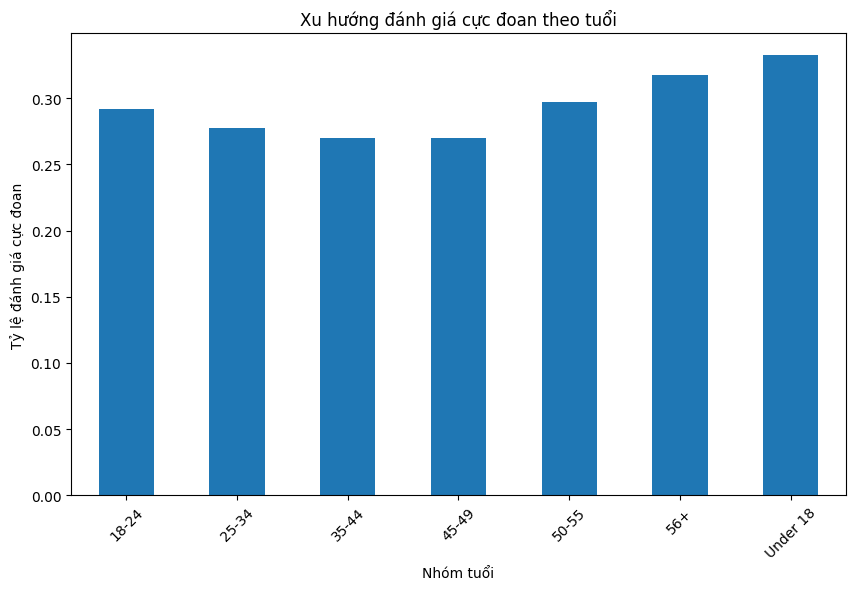

Young (<25): 0.297, Old (>=25): 0.278, Diff: 0.019


In [27]:
data['extreme'] = ((data['rating'] == 1) | (data['rating'] == 5)).astype(int)
extreme_rate = data.groupby('age_group')['extreme'].mean()
print("Tỷ lệ đánh giá cực đoan theo nhóm tuổi:")
print(extreme_rate)

plt.figure(figsize=(10, 6))
extreme_rate.plot(kind='bar')
plt.xlabel("Nhóm tuổi")
plt.ylabel("Tỷ lệ đánh giá cực đoan")
plt.title("Xu hướng đánh giá cực đoan theo tuổi")
plt.xticks(rotation=45)
plt.show()

young = data[data['age_group'].isin(['Under 18', '18-24'])]['extreme'].mean()
old = data[~data['age_group'].isin(['Under 18', '18-24'])]['extreme'].mean()
print(f"Young (<25): {young:.3f}, Old (>=25): {old:.3f}, Diff: {young - old:.3f}")

## 5. Phân Tích Mở Rộng

Liên hệ đến tâm lý người dùng hoặc ứng dụng thực tế.

### 5.1 Độ lệch chuẩn cao trong rating có thể phản ánh phân cực cảm xúc (emotional polarization) trong khán giả không?

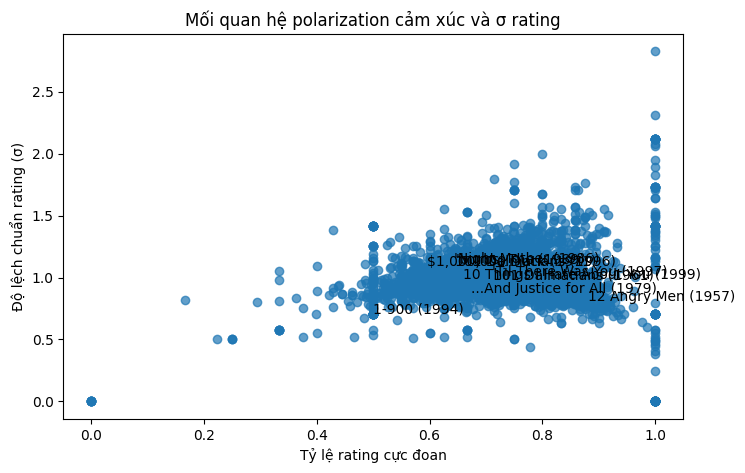

Pearson correlation: 0.138
Extreme ratings per title (Counter): {"One Flew Over the Cuckoo's Nest (1975)": 1564, 'Erin Brockovich (2000)': 1034, "Bug's Life, A (1998)": 1296, 'Ben-Hur (1959)': 587, 'Christmas Story, A (1983)': 1167}


In [28]:
from collections import Counter  # Từ PDF 13.1

# Tính σ per title
std_by_title = data.groupby('title')['rating'].std()

# Proxy emotional polarization: Tỷ lệ extreme ratings
data['extreme'] = ((data['rating'] <= 2) | (data['rating'] >= 4)).astype(int)
extreme_prop = data.groupby('title')['extreme'].mean()

plt.figure(figsize=(8, 5))
plt.scatter(extreme_prop, std_by_title, alpha=0.7)
plt.xlabel('Tỷ lệ rating cực đoan')
plt.ylabel('Độ lệch chuẩn rating (σ)')
plt.title('Mối quan hệ polarization cảm xúc và σ rating')
for title in std_by_title.index[:10]:  # Sample
    plt.annotate(title, (extreme_prop[title], std_by_title[title]))
plt.show()

corr = extreme_prop.corr(std_by_title)
print(f'Pearson correlation: {corr:.3f}')

extreme_counts = Counter(data[data['extreme'] == 1]['title'])
print('Extreme ratings per title (Counter):', dict(list(extreme_counts.items())[:5]))

### 5.2 Có thể tận dụng các phim có độ phân tán rating cao để thiết kế thuật toán gợi ý theo phong cách ‘khám phá’ (serendipity recommendation) không?

In [30]:
from collections import defaultdict, Counter  # Từ PDF 13.1

# High-σ movies (từ PDF 13.2: loc[active_titles])
ratings_by_title_real = data.groupby('title').size()
active_titles_real = ratings_by_title_real[ratings_by_title_real >= 250].index
high_sigma = data.groupby('title')['rating'].std().loc[active_titles_real].nlargest(20).index

print(f"High-σ movies (top 20%): {list(high_sigma[:5])}")  # Ví dụ top 5

# Serendipity score (proxy: weight σ cao cho khám phá, giảm similarity với user avg)
def serendipity_score(std_val, user_avg, diversity=0.5):
    similarity = abs(std_val - user_avg) / user_avg  # Proxy similarity (thấp → diverse)
    return std_val * (1 - similarity) + diversity  # High-σ + diversity = serendipity

user_avg = data['rating'].mean()  # Global avg ~3.58
rec_scores = defaultdict(float)
sample_titles = data['title'].unique()[:10]  # Sample 10 để demo nhanh
for title in sample_titles:
    std_t = data.groupby('title')['rating'].std().get(title, 1.0)  # .get() an toàn nếu missing
    score = serendipity_score(std_t, user_avg)
    rec_scores[title] = score

# Top serendipity recs (sort như top_counts từ PDF 13.1)
top_sero = sorted(rec_scores.items(), key=lambda x: x[1], reverse=True)[:5]
print("Top serendipity recommendations (high-σ weighted):", top_sero)

# Genres in high-σ (dùng data_exploded để có 'genre' - fix lỗi)
if 'genre' in data_exploded.columns:
    high_genres = Counter(data_exploded[data_exploded['title'].isin(high_sigma)]['genre'])
    print("Genres phổ biến ở high-σ (Counter):", dict(high_genres.most_common(5)))  # Top 5
else:
    print("Warning: 'genre' not found in data_exploded. Run preprocessing cell again.")
    # Fallback: Split 'genres' từ data gốc
    high_movies_genres = data[data['title'].isin(high_sigma)]['genres'].str.split('|').explode()
    high_genres = Counter(high_movies_genres)
    print("Fallback genres (Counter):", dict(high_genres.most_common(5)))

High-σ movies (top 20%): ['Dumb & Dumber (1994)', 'Blair Witch Project, The (1999)', 'Natural Born Killers (1994)', 'Tank Girl (1995)', 'Rocky Horror Picture Show, The (1975)']
Top serendipity recommendations (high-σ weighted): [('James and the Giant Peach (1996)', np.float64(0.7923144183425712)), ('Snow White and the Seven Dwarfs (1937)', np.float64(0.753467360655388)), ('Christmas Story, A (1983)', np.float64(0.7264730267912312)), ('Wizard of Oz, The (1939)', np.float64(0.7241413971765855)), ('Erin Brockovich (2000)', np.float64(0.7240958029863434))]
Genres phổ biến ở high-σ (Counter): {'Comedy': 7249, 'Horror': 4002, 'Drama': 2711, 'Action': 2301, 'Sci-Fi': 1974}


### 5.3 Liệu phim ‘gây chia rẽ’ có khả năng lan tỏa truyền thông cao hơn phim ‘được yêu thích đồng thuận’ không?

Viral proxy high-σ: 185.4
Viral proxy low-σ: 4297.9


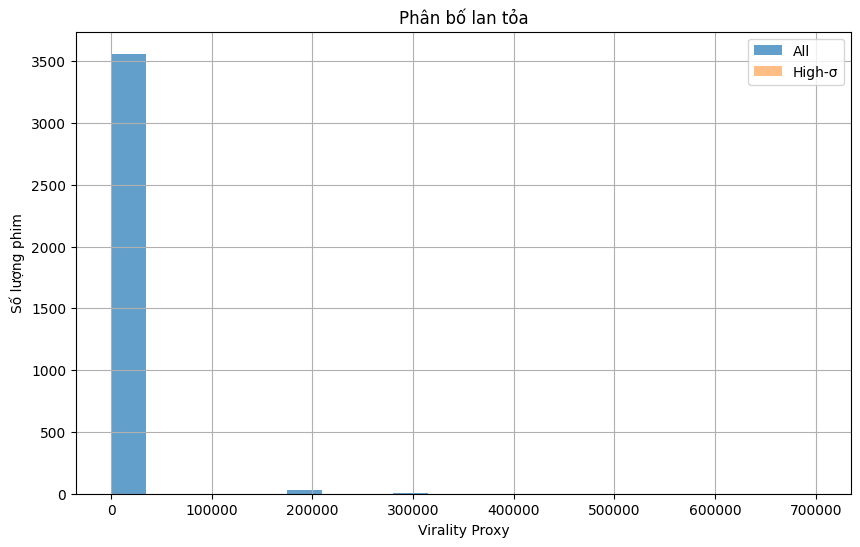

Buzz levels (Pure Python): {'Low Buzz': 3588, nan: 114, 'Medium': 3, 'High Buzz': 1}


In [31]:
def get_counts_pure(sequence):
    counts = defaultdict(int)
    for x in sequence:
        counts[x] += 1
    return counts

# Virality proxy
title_stats = data.groupby('title').agg({'rating': ['std', 'count', 'mean']}).round(2)
title_stats.columns = ['std', 'num_ratings', 'mean_rating']
title_stats['virality_proxy'] = title_stats['num_ratings'] / (title_stats['std'] + 1e-5)

high_sigma_titles = title_stats[title_stats['std'] > title_stats['std'].median()].index
low_sigma_titles = title_stats[title_stats['std'] <= title_stats['std'].median()].index

high_vir = title_stats.loc[high_sigma_titles, 'virality_proxy'].mean()
low_vir = title_stats.loc[low_sigma_titles, 'virality_proxy'].mean()
print(f"Viral proxy high-σ: {high_vir:.1f}")
print(f"Viral proxy low-σ: {low_vir:.1f}")

plt.figure(figsize=(10, 6))
title_stats['virality_proxy'].hist(bins=20, alpha=0.7, label='All')
title_stats.loc[high_sigma_titles, 'virality_proxy'].hist(bins=10, alpha=0.5, label='High-σ')
plt.xlabel('Virality Proxy')
plt.ylabel('Số lượng phim')
plt.title('Phân bố lan tỏa')
plt.legend()
plt.show()

buzz_bins = pd.cut(title_stats['virality_proxy'], bins=3, labels=['Low Buzz', 'Medium', 'High Buzz'])
buzz_counts = get_counts_pure(buzz_bins)
print("Buzz levels (Pure Python):", dict(buzz_counts))